# 项目：好莱坞电影数据分析

## 第一步：获取数据 (Mission Start)
我们使用Kaggle上最受欢迎的电影数据集之一：TMDB 5000 Movie Dataset。
它包含了大约5000部电影的信息，如预算、票房、评分、类型、关键词、演员、导演等。

### 1.导入库并加载数据

In [2]:
# 导入四个主要的数据处理和可视化库：

import pandas as pd   # pandas - 用于数据处理和分析
import numpy as np    # numpy - 用于数值计算
import matplotlib.pyplot as plt    # matplotlib.pyplot - 用于创建静态可视化图表
import seaborn as sns   # seaborn - 基于matplotlib的高级可视化库，提供更美观的样式和更简单的API


# 设置可视化风格
sns.set_style('whitegrid')  # 使用seaborn的白色网格风格，使图表更清晰易读
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False    # 用来正常显示负号

# 加载数据
movies_df = pd.read_csv('tmdb_5000_movies.csv')   # 读取电影基本信息数据
credits_df = pd.read_csv('tmdb_5000_credits.csv') # 读取演职人员信息数据

### 2.初步探索数据

In [3]:
print("Movies DataFrame Shape:", movies_df.shape)  # 显示movies_df的行数和列数
print("Credits DataFrame Shape:", credits_df.shape)  # 显示credits_df的行数和列数
movies_df.head() # 查看数据的前5行，默认显示前5行
movies_df.info() # 查看列的数据类型和缺失值（通过比较非空值与总行数）
movies_df.describe() # 查看数值型列的统计摘要：
# 功能：只对数值型列进行统计计算，包括：
# - count: 非空值数量
# - mean: 平均值
# - std: 标准差
# - min: 最小值
# - 25%: 第一四分位数
# - 50%: 中位数（第二四分位数）
# - 75%: 第三四分位数
# - max: 最大值

Movies DataFrame Shape: (4803, 20)
Credits DataFrame Shape: (4803, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  sp

,budget,id,popularity,revenue,runtime,vote_average,vote_count
count,4.803000e+03,4803.000000,4803.000000,4.803000e+03,4801.000000,4803.000000,4803.000000
mean,2.904504e+07,57165.484281,21.492301,8.226064e+07,106.875859,6.092172,690.217989
std,4.072239e+07,88694.614033,31.816650,1.628571e+08,22.611935,1.194612,1234.585891
min,0.000000e+00,5.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,7.900000e+05,9014.500000,4.668070,0.000000e+00,94.000000,5.600000,54.000000
50%,1.500000e+07,14629.000000,12.921594,1.917000e+07,103.000000,6.200000,235.000000
75%,4.000000e+07,58610.500000,28.313505,9.291719e+07,118.000000,6.800000,737.000000
max,3.800000e+08,459488.000000,875.581305,2.787965e+09,338.000000,10.000000,13752.000000


### 3.关键清洗步骤
合并数据集：根据电影ID将movies_df和credits_df合并。

In [4]:
# 在credits_df中，列名'movie_id'重命名为'id'以便与movies_df匹配
credits_df.rename(columns={'movie_id': 'id'}, inplace=True)
# 功能：将credits_df中的'movie_id'列重命名为'id'
# 参数说明：
# - columns={'movie_id': 'id'}：指定要重命名的列和新的列名
# - inplace=True：直接在原DataFrame上进行修改，而不是返回新的DataFrame
# 目的：使两个数据集有相同的连接键列名

# 合并数据集
df = pd.merge(movies_df, credits_df, on='id')
# 功能：基于'id'列将两个DataFrame合并为一个
# 参数说明：
# - movies_df：左侧DataFrame
# - credits_df：右侧DataFrame  
# - on='id'：指定用于连接的列名
# 默认使用内连接(inner join)，只保留两个DataFrame中都存在的id值

处理缺失值：检查并处理关键列（如budget, revenue, runtime）的缺失值。

In [5]:
# 检查缺失值
print(df[['budget', 'revenue', 'runtime']].isnull().sum())
# 功能：检查指定列中的缺失值数量
# 执行过程：
# 1. df[['budget', 'revenue', 'runtime']] - 选择这三列
# 2. .isnull() - 返回布尔值DataFrame，True表示缺失值
# 3. .sum() - 对每列的True值求和，得到缺失值数量

# 对于预算和票房为0的，可以认为是缺失值，用NaN替换后再删除或填充
df['budget'] = df['budget'].replace(0, np.NaN)
df['revenue'] = df['revenue'].replace(0, np.NaN)
# 功能：将预算和票房为0的值替换为NaN
# 原因：在电影数据中，预算或票房为0通常表示数据缺失或未记录，而不是实际值为0
# np.NaN 表示缺失值，便于后续的统一处理

# 删除关键列缺失的行
df.dropna(subset=['budget', 'revenue', 'runtime'], inplace=True)
# 功能：删除在指定列中存在缺失值的行
# 参数说明：
# - subset=['budget', 'revenue', 'runtime']: 只检查这些列的缺失值
# - inplace=True: 直接修改原DataFrame，不返回新的DataFrame
# 效果：任何在budget、revenue或runtime列有缺失值的行都会被删除

budget     0
revenue    0
runtime    2
dtype: int64


转换数据类型：genres, keywords, cast, crew等列是JSON格式的字符串，需要解析成可读的列表。

In [6]:
# 编写函数将JSON字符串转换为可读列表
import ast
# ast模块用于安全地解析和求值字符串形式的Python表达式

# 编写函数将JSON字符串转换为可读列表
def convert_json_column(text):
    list_obj = []
    # 创建空列表存储结果
    # 使用ast.literal_eval安全地解析字符串为Python对象
    # 比eval()更安全，只能解析字面量表达式
    for item in ast.literal_eval(text):
        list_obj.append(item['name'])   # 提取每个字典中的'name'值
    return list_obj

# 应用函数到需要的列
df['genres_list'] = df['genres'].apply(convert_json_column)  # 将genres列中的JSON字符串转换为类型名称列表
df['keywords_list'] = df['keywords'].apply(convert_json_column)  # 将keywords列转换为关键词名称列表
df['cast_list'] = df['cast'].apply(convert_json_column)  # 将cast列转换为演员名称列表
# 对于crew列，我们可能只提取导演
def get_director(text):
        # 遍历crew列表中的每个人员信息
    for item in ast.literal_eval(text):
        if item['job'] == 'Director':   # 检查职位是否为导演
            return item['name']   # 返回导演姓名
    return np.NaN  # 如果没有找到导演，返回缺失值
df['director'] = df['crew'].apply(get_director)  # 从crew列中提取导演姓名，创建新的director列

创建新特征：

利润率： profit_ratio = (revenue - budget) / budget

年份：从release_date中提取。

### 4.数据可视化

现在，让我们用清洗好的数据来回答一些有趣的问题。

#### 1.宏观趋势:电影行业这些年有何变化？

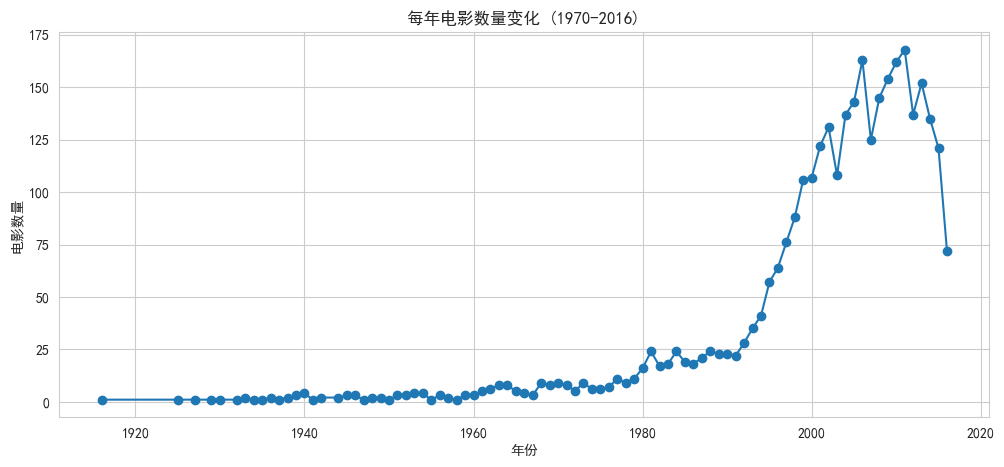

In [7]:
# 提取年份  
df['year'] = pd.to_datetime(df['release_date']).dt.year
#将release_date 列（字符串格式的日期）转换为 pandas 的 datetime 类型
# .dt.year : 从 datetime 对象中提取年份部分
# df['year'] = pd.to_datetime(df['release_date']).dt.year: 创建新列 year 存储提取的年份
# 按年份进行分组并计算统计指标
yearly_trend = df.groupby('year').agg({'id': 'count', 'budget': 'mean', 'revenue': 'mean', 'vote_average': 'mean'}).rename(columns={'id': 'movie_count'})
# - df.groupby('year') : 按年份对数据进行分组
# - .agg({...}) : 对每组应用聚合函数
# - 'id': 'count' : 统计每年的电影数量（计数）
# - 'budget': 'mean' : 计算每年的平均预算
# - 'revenue': 'mean' : 计算每年的平均票房
# - 'vote_average': 'mean' : 计算每年的平均评分
# - .rename(columns={'id': 'movie_count'}) : 将 id 列重命名为 movie_count （更直观）

# 绘制每年电影数量  
plt.figure(figsize=(12,5))  #创建12×5的画布
plt.plot(yearly_trend.index, yearly_trend['movie_count'], marker='o')   
# - yearly_trend.index : X轴数据（年份）
# - yearly_trend['movie_count'] : Y轴数据（电影数量）
# - marker='o' : 在数据点上显示圆形标记
plt.title('每年电影数量变化 (1970-2016)')#设置标题
plt.xlabel('年份')#设置x轴标签
plt.ylabel('电影数量')#设置y轴标签  
plt.show() #显示图表

#### 2.投资与回报：高预算等于高票房吗

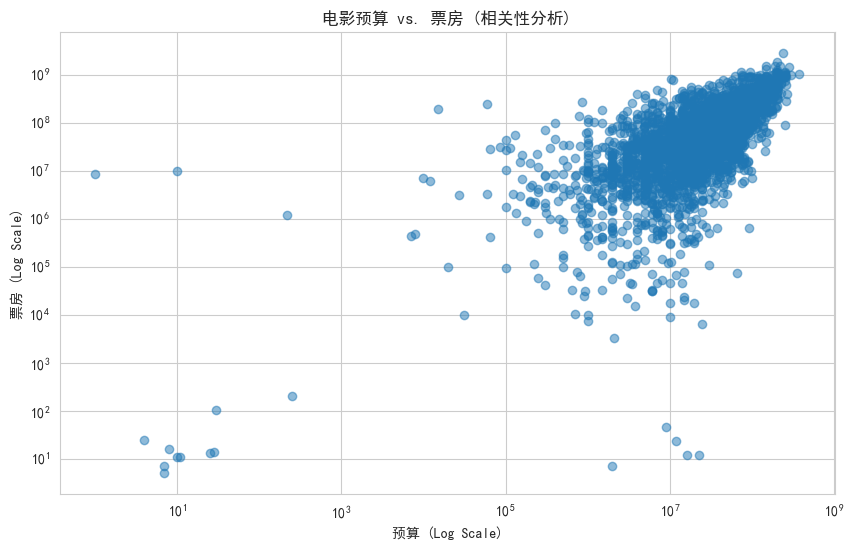

预算与票房的相关系数: 0.7053993306781376


In [11]:
plt.figure(figsize=(10,6))  #创建图形窗口，figsize=(10,6) 设置图形大小为10英寸宽×6英寸高
plt.scatter(df['budget'], df['revenue'], alpha=0.5)  #绘制散点图 
# 参数说明：
# - df['budget']: x轴数据（电影预算）
# - df['revenue']: y轴数据（电影票房）
# - alpha=0.5: 设置点的透明度为50%，便于观察重叠的数据点

#设置坐标轴为对数尺度
plt.xscale('log') # x轴使用对数尺度
plt.yscale('log') # y轴使用对数尺度
# 使用对数坐标轴的原因：
# 1. 预算和票房数据跨度极大（从几万到几亿美元）
# 2. 对数尺度可以更好地展示数据的相对关系
# 3. 使数据点分布更加均匀，便于观察趋势

# 设置坐标轴标签
plt.xlabel('预算 (Log Scale)')# x轴标签，注明使用对数尺度
plt.ylabel('票房 (Log Scale)')# y轴标签，注明使用对数尺度
plt.title('电影预算 vs. 票房 (相关性分析)')#设置标题 
plt.show() #显示图形

# 计算相关系数
print("预算与票房的相关系数:", df['budget'].corr(df['revenue']))
# df['budget'].corr(df['revenue']) 计算皮尔逊相关系数
# 相关系数范围：-1 到 1
# 正值表示正相关，负值表示负相关
# 接近0表示弱相关，接近±1表示强相关

#### 3.电影类型分析：什么类型最卖座？

C:\Users\32741\AppData\Local\Temp\ipykernel_24312\3757848469.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Genre', data=genres_df, palette='viridis')


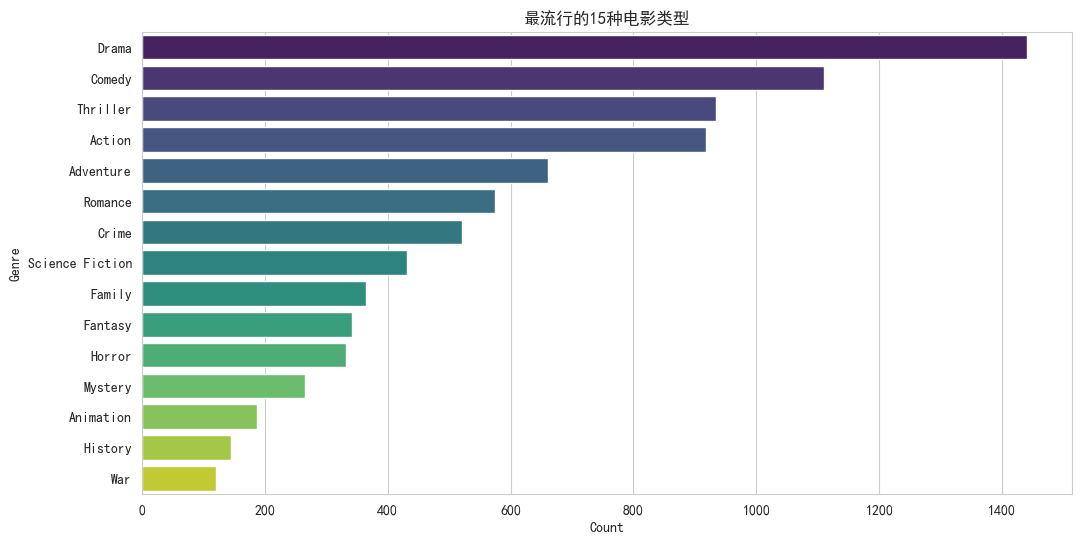

In [12]:
# 将类型列表展开成多行
from collections import Counter # 导入Counter类用于计数
genres_list = df['genres_list'].tolist()# 将genres_list列转换为列表的列表

all_genres = [genre for sublist in genres_list for genre in sublist]
# 使用列表推导式展开嵌套列表
# 将[['Drama', 'Romance'], ['Action', 'Adventure']]转换为['Drama', 'Romance', 'Action', 'Adventure']

genre_count = Counter(all_genres)# 统计每种类型的出现次数

# 绘制最流行的电影类型
genres_df = pd.DataFrame(genre_count.most_common(15), columns=['Genre', 'Count'])
# most_common(15)获取出现次数最多的15种类型
# 创建DataFrame，列名为'Genre'和'Count'

plt.figure(figsize=(12,6))#设置图形大小为12×6
sns.barplot(x='Count', y='Genre', data=genres_df, palette='viridis')
# 创建水平条形图
# x='Count': x轴显示计数
# y='Genre': y轴显示类型名称  
# palette='viridis': 使用viridis颜色方案

plt.title('最流行的15种电影类型')
plt.show()


#### 4.导演之王：谁是最"摇钱树"的导演？

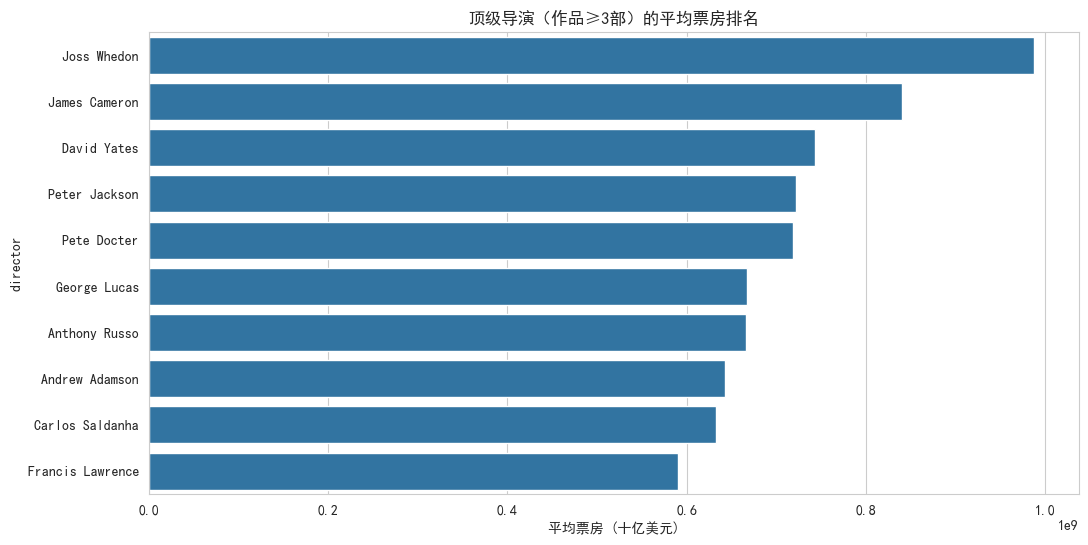

In [13]:
# 分组计算导演的平均票房或利润
director_stats = df.groupby('director').agg({'revenue': 'mean', 'id': 'count'}).rename(columns={'id': 'movie_count', 'revenue': 'avg_revenue'})
# 详细分解：
# 1. df.groupby('director') - 按导演姓名分组
# 2. .agg({'revenue': 'mean', 'id': 'count'}) - 对每个导演组计算：
#    - revenue列的均值（平均票房）
#    - id列的计数（电影数量）
# 3. .rename(columns={'id': 'movie_count', 'revenue': 'avg_revenue'}) - 重命名列使其更易理解

# 过滤掉电影数量太少的导演
top_directors = director_stats[director_stats['movie_count'] >= 3].sort_values('avg_revenue', ascending=False).head(10)
# 详细分解：
# 1. director_stats['movie_count'] >= 3 - 筛选出拍摄至少3部电影的导演
#    （避免单部电影成功的偶然性，确保统计显著性）
# 2. .sort_values('avg_revenue', ascending=False) - 按平均票房降序排序
# 3. .head(10) - 取前10名

plt.figure(figsize=(12,6))
sns.barplot(x='avg_revenue', y=top_directors.index, data=top_directors)
# 创建水平条形图：
# - x='avg_revenue': x轴显示平均票房
# - y=top_directors.index: y轴显示导演姓名
# - data=top_directors: 数据源

plt.title('顶级导演（作品≥3部）的平均票房排名')# 标题
plt.xlabel('平均票房 (十亿美元)') # x轴标签
plt.show()

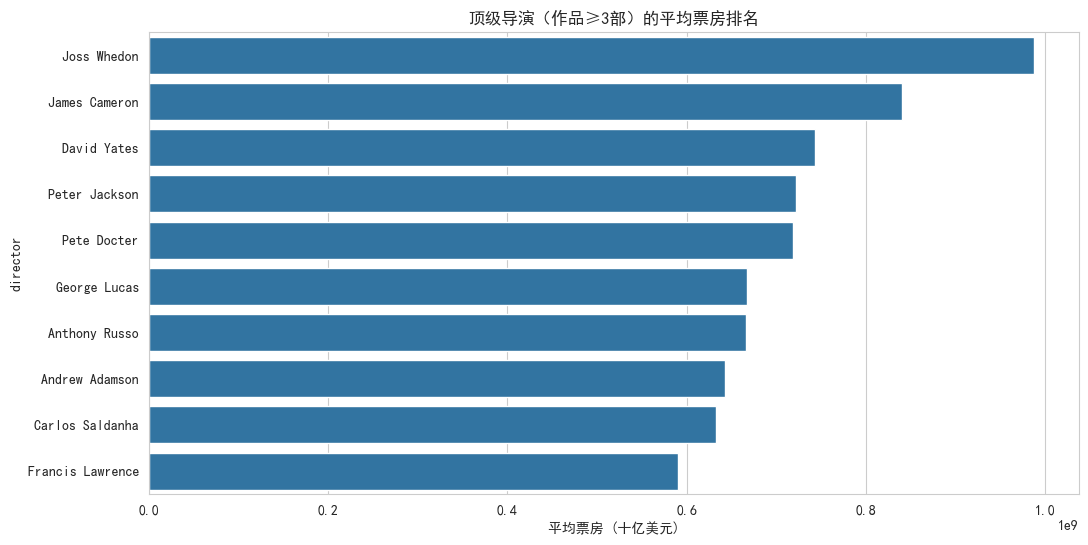

参演≥3部电影，平均票房最高的Top 5演员：
                 actor  movie_count   avg_revenue
11229       Dileep Rao            3  1.234770e+09
22142   Joseph O'Brien            3  1.165123e+09
5394   Brian Schaeffer            4  1.099520e+09
24257     Kevin Dorman            3  1.094323e+09
17896   Jahnel Curfman            3  1.079832e+09


C:\Users\32741\AppData\Local\Temp\ipykernel_24312\2580122954.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='avg_revenue', y='actor', data=top_actors, palette='magma')


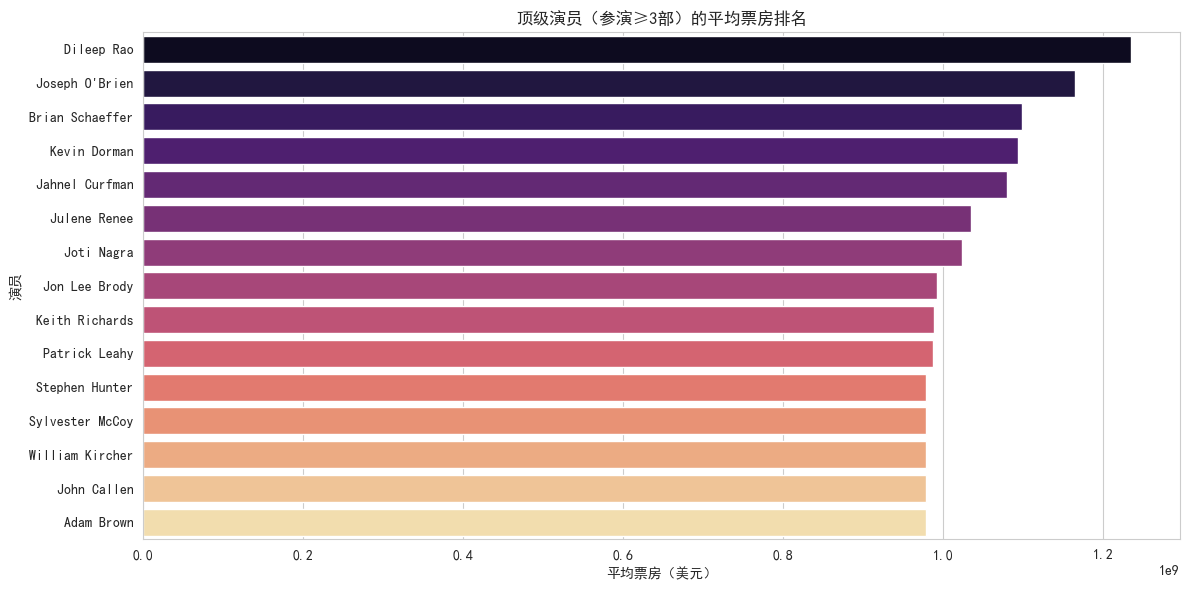

In [14]:
# 新增：演员号召力分析（参演电影平均票房）
# 将演员列表展开为多行：一行即“演员-电影”的映射
actors_df = df[['revenue', 'cast_list']].explode('cast_list').rename(columns={'cast_list': 'actor'})
    # 详细分解：
# 1. df[['revenue', 'cast_list']] - 选择需要的列
# 2. .explode('cast_list') - 将cast_list列中的列表展开，每个元素成为单独的行
#    示例：一行['Tom Hanks', 'Meg Ryan']变成两行
# 3. .rename(columns={'cast_list': 'actor'}) - 重命名列

# 统计每位演员的参演次数和平均票房
actor_stats = actors_df.groupby('actor', dropna=True).agg(

    movie_count=('revenue', 'count'),# 统计参演电影数量

    avg_revenue=('revenue', 'mean')# 计算平均票房
).reset_index()# 将groupby结果转换为DataFrame

# 为避免样本过少造成偏差，过滤参演次数不足的演员（可按需调整阈值）
min_movies = 3 # 统计参演电影数量
top_actors = (
    actor_stats[actor_stats['movie_count'] >= min_movies] # 过滤参演≥3部的演员
    .sort_values('avg_revenue', ascending=False)# 按平均票房降序排序
    .head(15)# 取前15名
)

# 打印Top 5用于快速检查
print(f"参演≥{min_movies}部电影，平均票房最高的Top 5演员：")
print(top_actors[['actor', 'movie_count', 'avg_revenue']].head(5))

# 可视化Top 15演员的平均票房
plt.figure(figsize=(12, 6))
sns.barplot(x='avg_revenue', y='actor', data=top_actors, palette='magma')
# 创建水平条形图：
# - x轴：平均票房
# - y轴：演员姓名  
# - 使用magma配色方案

plt.title(f'顶级演员（参演≥{min_movies}部）的平均票房排名')
plt.xlabel('平均票房（美元）')
plt.ylabel('演员')
plt.tight_layout() # 自动调整布局，避免标签被截断
plt.show()
